# 02 - EDA: LoL Diamond Ranked Games
Contexto do dataset: ~10k partidas ranqueadas (Diamond a Master). 

Cada linha é uma partida com estatísticas dos primeiros 10 minutos. 

Colunas com prefixo blue são do time azul, red do vermelho. 

A coluna blueWins é o resultado: 1 = azul ganhou, 0 = vermelho ganhou.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/high_diamond_ranked_10min.csv')
# print(df.shape)
# print(df.head())

## Nível 1 — Exploração básica

### Quantas partidas e quantas colunas tem o dataset?
#### → .shape, .info()

In [9]:
print('Qtd de linhas e colunas:', df.shape)
print(df.info())


Qtd de linhas e colunas: (9879, 40)
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 no

### Existem valores nulos? Em quais colunas?
#### → .isnull().sum()

In [10]:
df.isnull().sum()

gameId                          0
blueWins                        0
blueWardsPlaced                 0
blueWardsDestroyed              0
blueFirstBlood                  0
blueKills                       0
blueDeaths                      0
blueAssists                     0
blueEliteMonsters               0
blueDragons                     0
blueHeralds                     0
blueTowersDestroyed             0
blueTotalGold                   0
blueAvgLevel                    0
blueTotalExperience             0
blueTotalMinionsKilled          0
blueTotalJungleMinionsKilled    0
blueGoldDiff                    0
blueExperienceDiff              0
blueCSPerMin                    0
blueGoldPerMin                  0
redWardsPlaced                  0
redWardsDestroyed               0
redFirstBlood                   0
redKills                        0
redDeaths                       0
redAssists                      0
redEliteMonsters                0
redDragons                      0
redHeralds    

### Qual a taxa de vitória do time azul? E do vermelho?
#### → .value_counts(), .mean()

In [11]:
df['blueWins'].mean()

np.float64(0.4990383642069035)

In [12]:
# 0 → falso / não aconteceu / perdeu
# 1 → verdadeiro / aconteceu / ganhou
df['blueWins'].value_counts()

blueWins
0    4949
1    4930
Name: count, dtype: int64

### Quais são as estatísticas básicas das colunas numéricas?
#### → .describe()

In [13]:
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


## Nível 2 — Filtragem e agrupamento

### Filtre as partidas onde o azul conseguiu o First Blood (blueFirstBlood == 1). Qual a taxa de vitória nessas partidas? Compare com a taxa geral.
#### → df[ condição ]['blueWins'].mean()

In [46]:
df['blueWins'].value_counts(normalize=True) # O normalize=True transforma as contagens em proporções automaticamente.

blueWins
0    0.500962
1    0.499038
Name: proportion, dtype: float64

In [63]:
print('Taxa de vitorias em que o lado azul pegou o FirstBlood:', round(df[df['blueFirstBlood'] == 1]['blueWins'].mean(),3))
print('Taxa de vitorias do lado azul:', round(df['blueWins'].mean(),3))
print('O lado azul quando começa com o FirstBlood tem um aumento de', round(df[df['blueFirstBlood'] == 1]['blueWins'].mean() - df['blueWins'].mean(),3), 'na chance de vencer a partida!')

Taxa de vitorias em que o lado azul pegou o FirstBlood: 0.599
Taxa de vitorias do lado azul: 0.499
O lado azul quando começa com o FirstBlood tem um aumento de 0.1 na chance de vencer a partida!


### Qual a média de kills, mortes e assists do azul nas partidas que ganhou vs perdeu?
#### → .groupby()[ ].mean()

In [71]:
round(df.groupby('blueWins')[['blueKills', 'blueDeaths', 'blueAssists']].mean(),3)


,blueKills,blueDeaths,blueAssists
blueWins,,,
0,5.170,7.131,5.523
1,7.202,5.140,7.772


### Compare o gold diff (blueGoldDiff) entre partidas que o azul ganhou e perdeu. O gold realmente importa?
#### → .groupby()[ ].mean()

In [75]:
df.groupby('blueWins')['blueGoldDiff'].mean()

blueWins
0   -1237.066680
1    1270.718053
Name: blueGoldDiff, dtype: float64

### Filtre partidas onde o azul estava perdendo no gold (blueGoldDiff < 0) mas mesmo assim ganhou. Quantas são? Que porcentagem do total representa?
#### → df[ (condição1) & (condição2) ]

In [ ]:
df[(df['blueGoldDiff'] < 0) & (df['blueWins'] == 1)][['blueWins','blueWardsPlaced',
    'blueWardsDestroyed', 
    'blueFirstBlood', 
    'blueKills', 
    'blueDeaths', 
    'blueAssists', 
    'blueEliteMonsters', 
    'blueDragons'
]]

,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons
9,1,13,1,1,4,5,5,1,1
14,1,15,3,1,4,4,4,0,0
24,1,33,3,0,6,9,10,0,0
43,1,12,2,1,5,5,3,0,0
48,1,15,2,0,2,3,2,1,0
...,...,...,...,...,...,...,...,...,...
9840,1,15,4,0,4,6,7,0,0
9842,1,16,8,0,4,7,7,1,0
9852,1,38,6,0,6,6,9,1,0
9860,1,85,3,0,8,7,11,1,0


In [ ]:
total_win_gold_diff = df[(df['blueGoldDiff'] < 0) & (df['blueWins'] == 1)][['blueWins']].sum()
percent_of_total = total_win_gold_diff / len(df)
print('Total de vitorias mesmo com Gold atras:', total_win_gold_diff.values[0])
print(f'Que porcentagem do total representa? {round(percent_of_total.values[0] * 100, 2)}%')


Total de vitorias mesmo com Gold atras: 1353
Que porcentagem do total representa? 13.7%


## Nível 3 — Visualização

### Gráfico de barras: taxa de vitória do azul com e sem First Blood.
#### → .groupby()[ ].mean().plot(kind= )

Text(0, 0.5, 'Taxa de vitória')

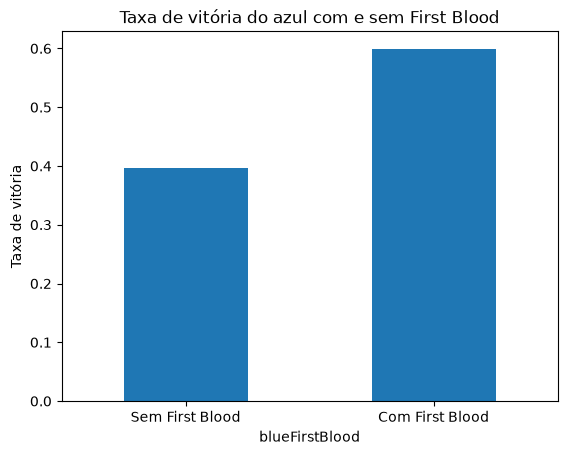

In [152]:
ax = df.groupby('blueFirstBlood')['blueWins'].mean().plot(kind='bar')
ax.set_xticklabels(['Sem First Blood', 'Com First Blood'], rotation=0)
ax.set_title('Taxa de vitória do azul com e sem First Blood')
ax.set_ylabel('Taxa de vitória')

### Histograma da distribuição do gold difference. O que você observa?
#### → .plot(kind='hist') ou sns.histplot()

<Axes: ylabel='Frequency'>

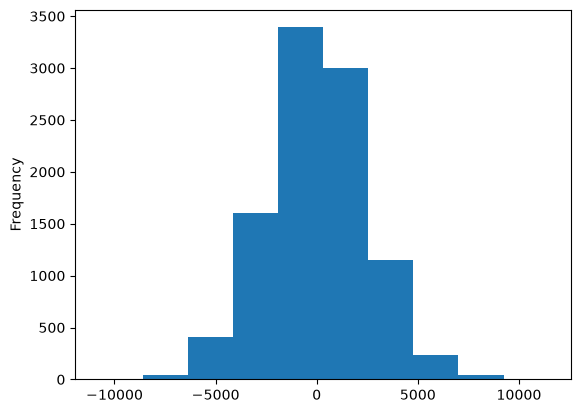

In [161]:
df['blueGoldDiff'].plot(kind='hist')


### 📊 Observação
A maioria das partidas tem gold difference próximo de zero, 
levemente positivo para o azul. Diferenças extremas são raras,
sugerindo que partidas equilibradas no early game são mais comuns.

### Compare a média de kills do azul em partidas ganhas vs perdidas, junto com as kills do vermelho.
#### → .groupby()[[ , ]].mean().plot(kind= )

In [168]:
round(df.groupby('blueWins')[['blueKills', 'redKills']].mean(),2)

,blueKills,redKills
blueWins,,
0,5.17,7.13
1,7.20,5.14


<Axes: xlabel='blueWins'>

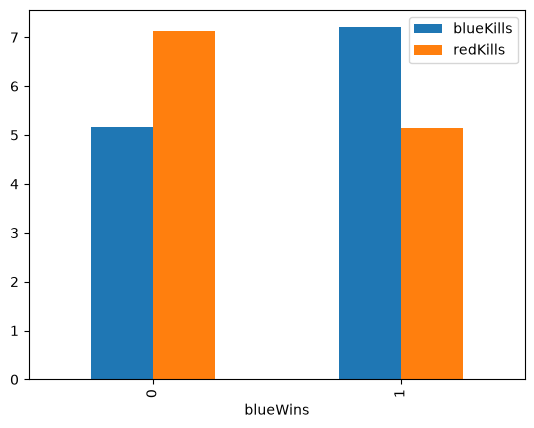

In [ ]:
df.groupby('blueWins')[['blueKills', 'redKills']].mean().plot(kind='bar')


### 📊 Observação

Quando o time azul **perde**, ele tende a ter menos kills que o vermelho (5.17 vs 7.13).
Quando o time azul **ganha**, o padrão se inverte — azul com mais kills (7.20 vs 5.14).

A diferença é quase simétrica: o time vencedor tem em média **~2 kills a mais** 
que o perdedor, independente do lado.

Isso sugere que kills aos 10 minutos pode ser uma feature relevante 
para prever o resultado da partida.

## Desafio bônus ★

### Crie uma coluna blueKDA = (kills + assists) / deaths do time azul. Cuidado com divisão por zero 

### — pesquise como usar .clip() ou .replace() para evitar. Compare o KDA médio em partidas ganhas vs perdidas.

In [17]:
df['blueKDA'] = round((df['blueKills'] + df['blueAssists']) / df['blueDeaths'], 2)
df['blueKDA'] = df['blueKDA'].replace([np.inf, -np.inf], np.nan)

In [18]:
round(df.groupby('blueWins')[['blueKDA']].mean(),2)

,blueKDA
blueWins,
0,1.82
1,3.85


Text(0, 0.5, 'KDA')

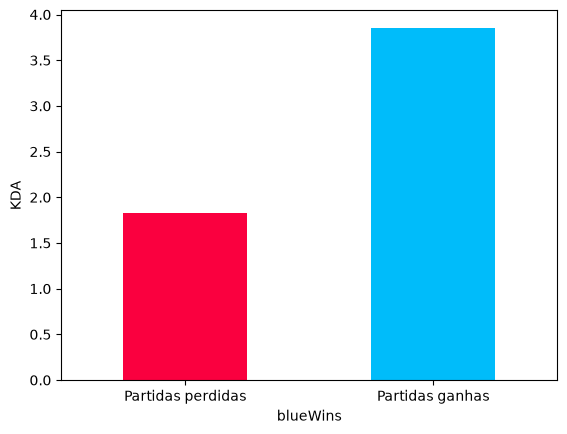

In [19]:
ax = df.groupby('blueWins')['blueKDA'].mean().plot(kind='bar', color=['#FA003F', '#00BCFA'])
ax.set_xticklabels(['Partidas perdidas', 'Partidas ganhas'],rotation=0)
ax.set_ylabel('KDA')